# 08 — Feature importance and SHAP explanations

What the model relies on, and why it called one specific flow an attack — including an assumption the data overturned.

**Pipeline module:** `src/explainability.py`

*Every number and figure below was produced by the pipeline in `src/`. This
notebook reads those results; it does not re-implement them.*

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import Image, display

TABLES = ROOT / "results" / "tables"
FIGURES = ROOT / "results" / "figures"

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

def table(name, **kw):
    """Read one of the pipeline's result tables."""
    return pd.read_csv(TABLES / name, **kw)

def figure(name):
    """Display one of the pipeline's figures."""
    return Image(filename=str(FIGURES / name))

print(f"project root: {ROOT}")

project root: C:\Users\babu\OneDrive\Desktop\ML Project


## Two views of importance

They answer different questions and disagree sharply here.

| Measure | Question | Weakness |
|---|---|---|
| **Gain** | How much did this feature reduce impurity *while the model was built*? | Biased toward features with many distinct values; describes the **training** data |
| **Permutation** | How much does test F1 **drop** if this feature's values are shuffled? | Slower, but measures what the model relies on for **unseen** traffic |

In [2]:
imp = table("feature_importance_binary.csv", index_col=0)
imp[["gain", "permutation", "gain_rank", "permutation_rank", "rank_shift"]].head(12).round(5)

,gain,permutation,gain_rank,permutation_rank,rank_shift
Destination Port,0.00663,0.14319,10.0,1.0,9.0
Fwd Packet Length Max,0.27769,0.07973,2.0,2.0,0.0
Init_Win_bytes_forward,0.00331,0.06652,14.0,3.0,11.0
Bwd Header Length,0.05173,0.03240,4.0,4.0,0.0
Init_Win_bytes_backward,0.01196,0.02816,7.0,5.0,2.0
Bwd Packets/s,0.00831,0.02700,9.0,6.0,3.0
Packet Length Variance,0.47046,0.02131,1.0,7.0,-6.0
Fwd IAT Min,0.00411,0.01563,13.0,8.0,5.0
min_seg_size_forward,0.00835,0.00903,8.0,9.0,-1.0
Fwd Header Length,0.04642,0.00711,5.0,10.0,-5.0


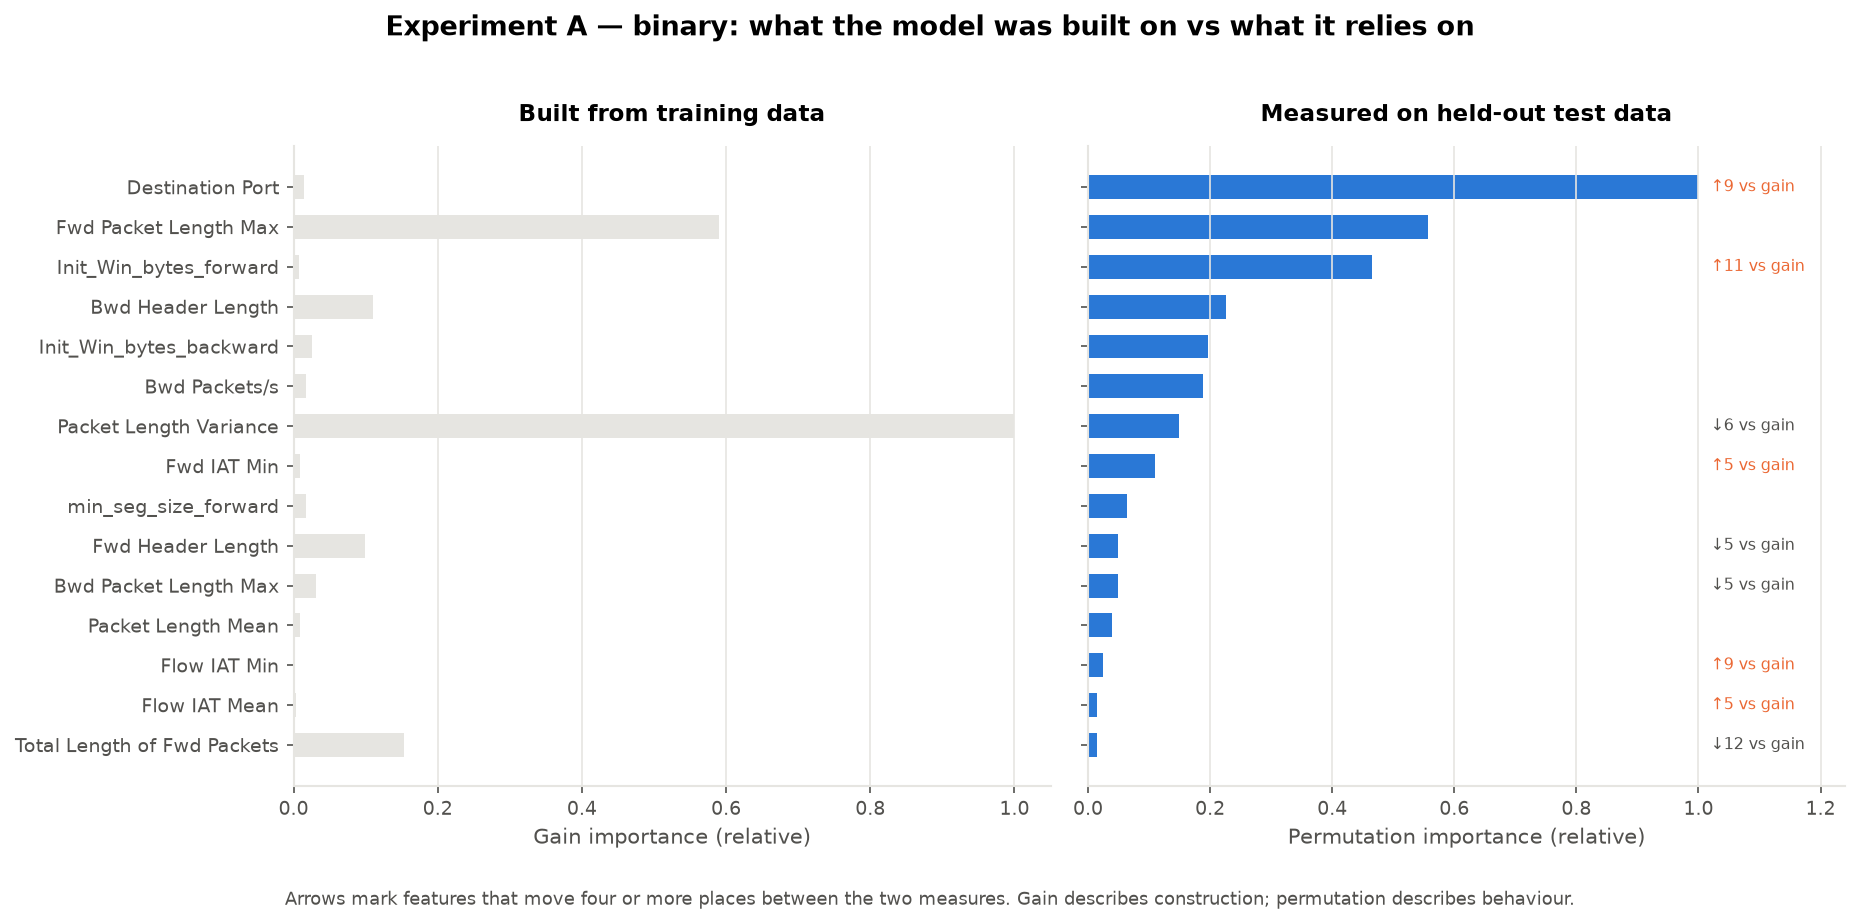

In [3]:
figure("18_feature_importance_binary.png")

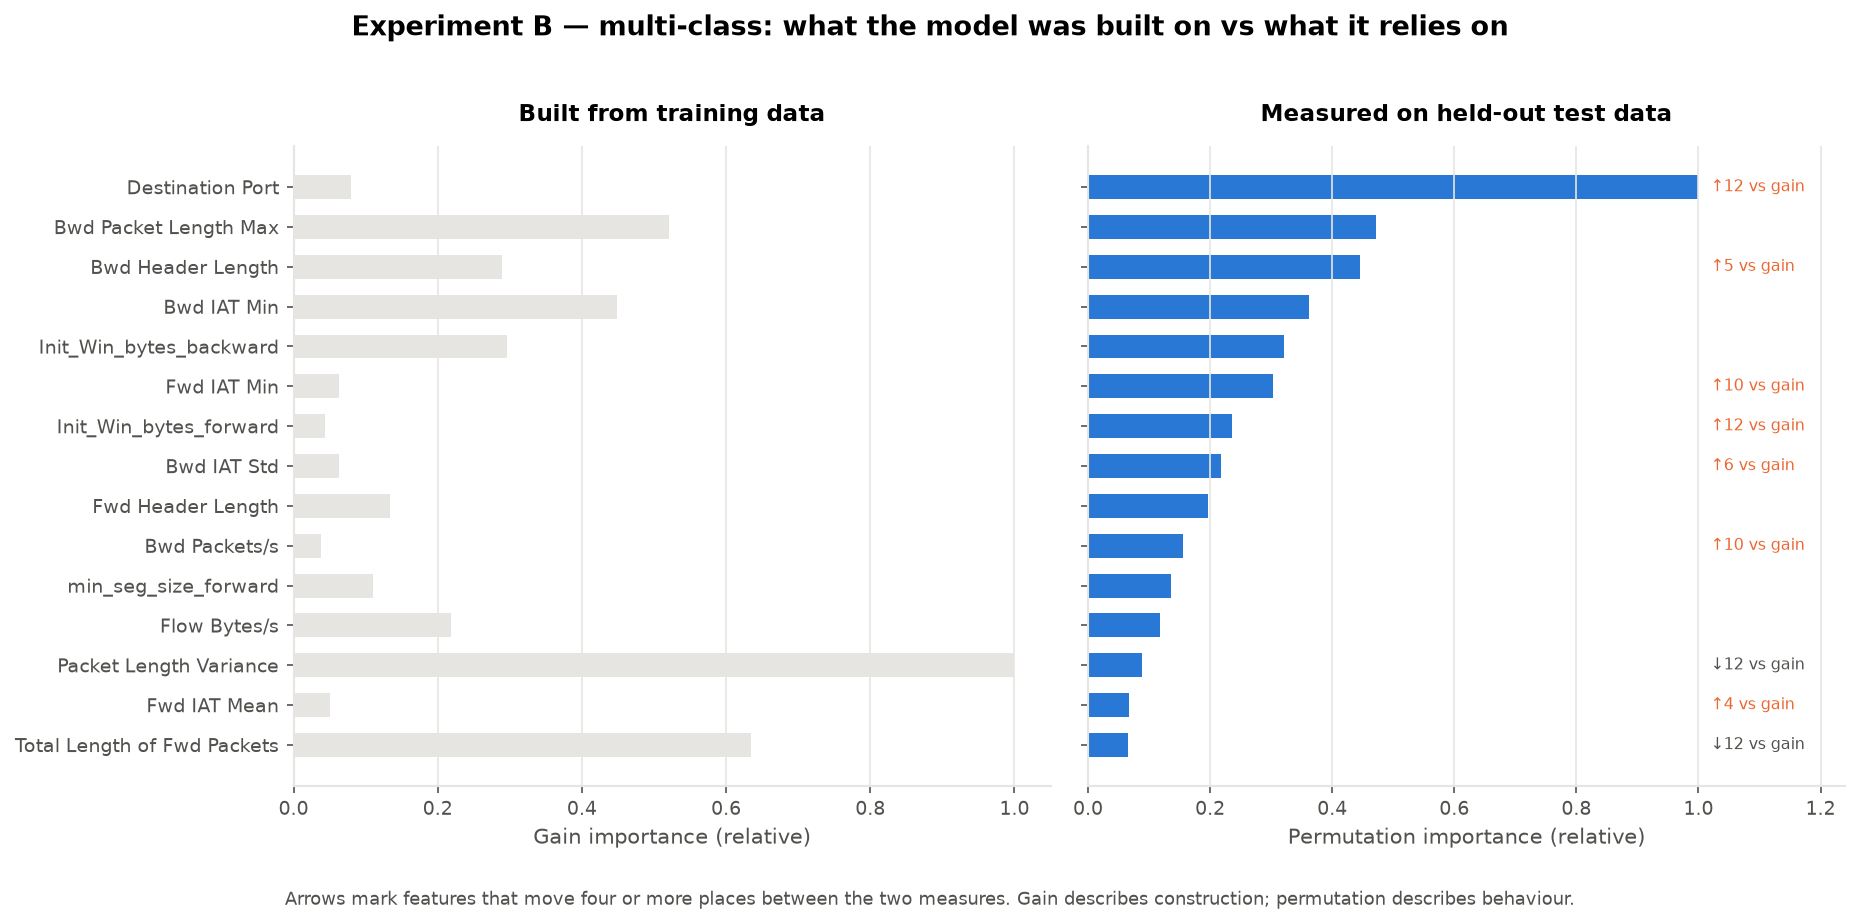

In [4]:
figure("18b_feature_importance_multi.png")

### Destination Port: #10 by gain, #1 by permutation

It barely separates attack from benign — both have a median destination port of 80.
But it separates attack *types* decisively:

| Class | Median destination port | Service |
|---|---|---|
| Brute Force | 21 | FTP |
| BENIGN · DoS · DDoS · Web Attack | 80 | HTTP |
| Infiltration · Heartbleed | 444 | service port |
| PortScan | 3390 | beside RDP's 3389 |
| Bot | 8080 | HTTP alternate |

Which is why permutation importance ranks it first on the multi-class task at 0.29759,
more than double the runner-up, while gain placed it #13.

## Global SHAP

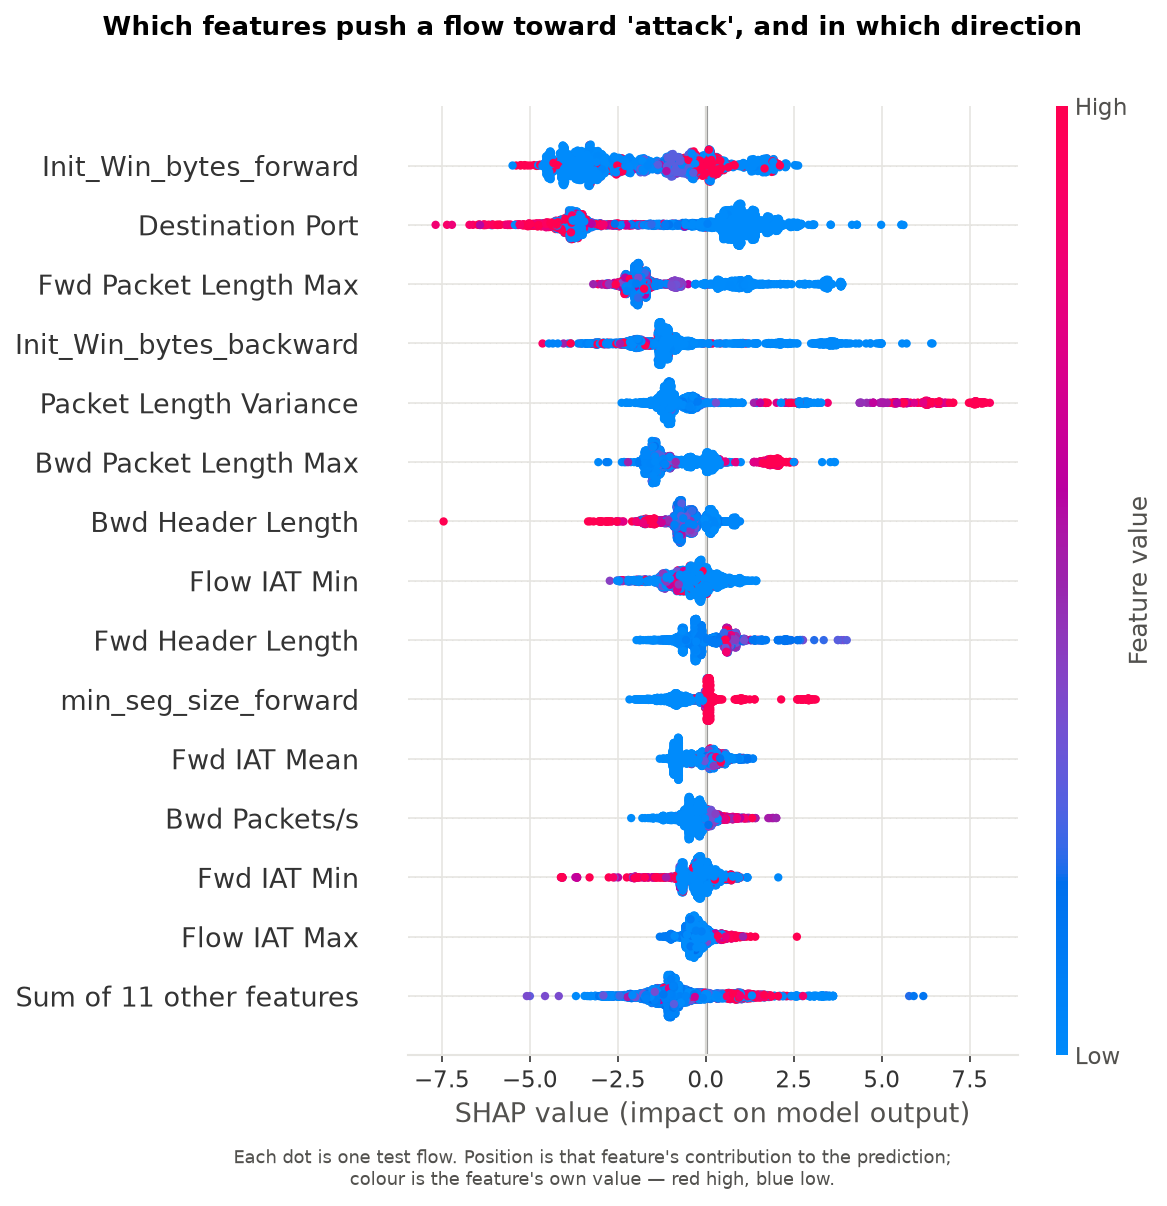

In [5]:
figure("19_shap_global.png")

### An assumption the data overturned

The intuitive story about attack traffic is that it is **uniform** — machine-generated
packets of consistent size, unlike messy human browsing. It reads well. It is wrong.

| | Packet Length Variance (median) |
|---|---|
| BENIGN | 945 |
| ATTACK | 2,101,995 |

A factor of roughly **2,200 in the opposite direction**. A flood mixes tiny control
packets with large payloads inside a single flow; ordinary browsing sits near a
consistent MTU. The *variance* is the signature, and the beeswarm above shows high
values pushing hard toward ATTACK.

This is worth stating plainly: the plausible explanation and the true one were not the
same, and only measurement separated them.

## Local SHAP — explaining one flow

A global summary says what matters on average. An analyst looking at a single alert
needs the reason for *that* flow.

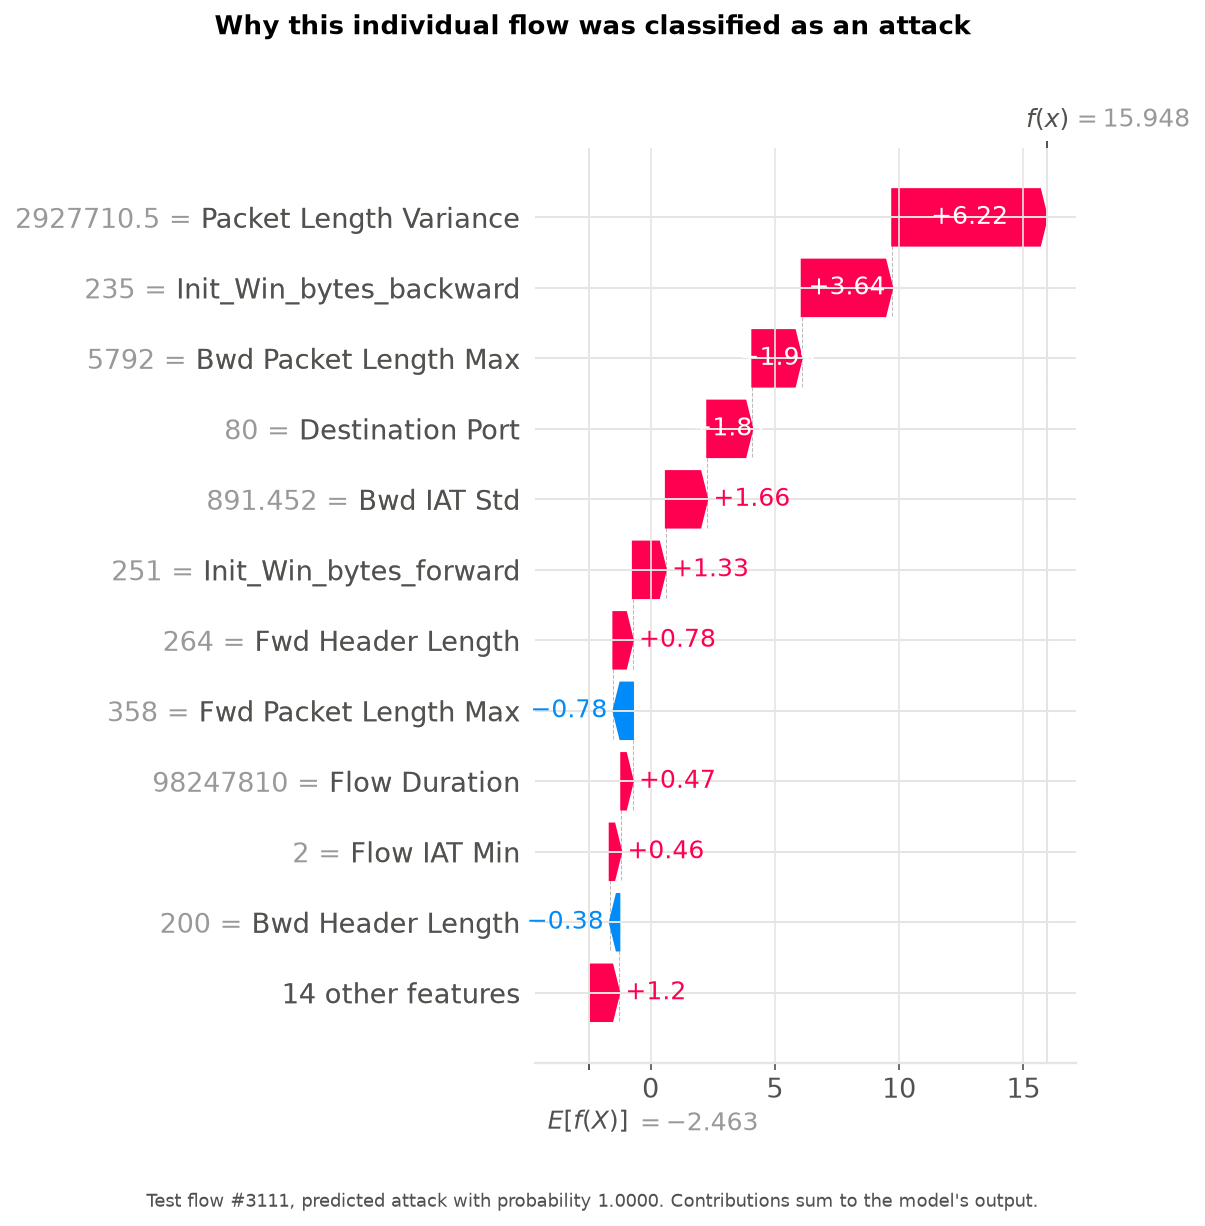

In [6]:
figure("20_shap_local.png")

| Feature | Flow value | Contribution | Direction |
|---|---|---|---|
| Packet Length Variance | 2,927,710 | +6.22 | toward ATTACK |
| Init_Win_bytes_backward | 235 | +3.64 | toward ATTACK |
| Bwd Packet Length Max | 5,792 | +1.99 | toward ATTACK |
| Destination Port | 80 | +1.81 | toward ATTACK |
| Fwd Packet Length Max | 358 | −0.78 | toward BENIGN |

Starting from a baseline of −2.463, the contributions carry the output to +15.948 and
sum exactly to it.

This is the difference between an alert and an *actionable* alert: an analyst can see
that a packet-length variance of 2.9 million on port 80 is what triggered it. The same
explanation is shown for every prediction in the Streamlit demo:

```bash
streamlit run app/app.py
```